# 1 - PROBLEM DEFINITION

En este laboratorio corresponde a la aplicacion del aprendizaje automatica empleando 3 modelos de regresion en Python. La tematica a abordar:
**Innovation and Technological Change -> Internet**, utilizando la grafica y data del **Number of people using the Internet**.

**Objetivo:** Predecir la cantidad estimada de usuarios de Internet dependiendo su crecimiento con respecto al año de un pais.

**Datos:** Se trabajará con archivos .csv con datos de tipo númerico y texto. Principalmente utilizaremos los datos presentes en el archivo number-of-internet-users.csv, el cual contiene la cantidad de usuarios de Internet con la que cuentan diferentes paises a través de los años.

# 2 - DATA COLLECTION AND PRE-PROCESSING

Se declaran las bibliotecas para utilizar en el laboratorio

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
import random
from matplotlib.ticker import ScalarFormatter
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

Obtiene el archivo .csv desde el repositorio de GitHub

Importo los datos en "csv", contiene las columnas "Entity", "Year", "Number of Internet users". No se considera la columna "Code" (el codigo de los paises), debido que no aporta informacion en el laboratorio.

In [4]:
csv = pd.read_csv("./number-of-internet-users.csv", low_memory = False, sep = ",", usecols = ["Entity", "Year", "Number of people using the Internet"])
csv


,Entity,Year,Number of people using the Internet
0,Afghanistan,1990,0.000000e+00
1,Afghanistan,2001,9.579402e+02
2,Afghanistan,2002,9.751404e+02
3,Afghanistan,2003,1.998036e+04
4,Afghanistan,2004,2.492930e+04
...,...,...,...
6471,Zimbabwe,2020,4.549156e+06
6472,Zimbabwe,2021,5.148690e+06
6473,Zimbabwe,2022,5.826078e+06
6474,Zimbabwe,2023,6.319780e+06


Grafico de la csv antes de aplicar el pre-procesamiento

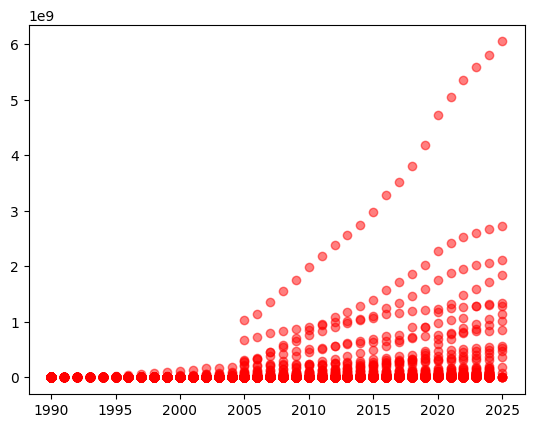

In [5]:
x = csv['Year']
y = csv['Number of people using the Internet']

graph_point = plt.scatter(x, y, marker = 'o', c = 'red', alpha = 0.5)
graph_point

Se eliminan las tuplas bajo las siguientes condiciones:

1.   Los años donde los usuarios en internet son iguales 0
2.   Las entidades que representa una categoria para agrupas paises
3.   Las entidades que representa regiones del mundo
4.   Paises cuyo numero de personas de internet es disperso en comparacion con el resto

La explicacion de la eliminacion se debe a:

* [ 1. ] : Elimina las tuplas que falta informacion de los usuarios de internet de un año, evitando trabajar con tuplas que no aportan informacion al momento de aplicar los modelos de regresion

* [ 2. y 3. ] : Elimina las entidades que son agrupaciones de paises. No se trabajara con dichas entidades, debido que cada pais a lo largo de los años tiene su taza de crecimineto de personas de internet (sean bajos o altos). Por ende, es posible los resultados no representa la realidad de cada pais.

* [ 4. ]: Elimina las entidad cuyos valores de personas en internet son atipicos, dado que puede impactar en las funciones de regresion. Aplicando este punto, puede mejorar la presicion de cada funcion.

In [6]:
#Eliminar tuplas cuyos usuarios de internet son iguales a 0

csv = csv.drop(csv[csv['Number of people using the Internet'] == 0].index)
print("Total de tuplas = " + str(len(csv)))

Total de tuplas = 6225


In [7]:
#Eliminar las tuplas cuya entidad es una categoria

deleteCATEGORY = ['High-income countries', 'Low-income countries', 'Lower-middle-income countries' , 'Upper-middle-income countries']
csv = csv.drop(csv[csv['Entity'].isin(deleteCATEGORY)].index)
print("Total de tuplas = " + str(len(csv)))

Total de tuplas = 6141


In [8]:
#Eliminar las tuplas cuya entidad corresponde a una region

deleteREGION = ['World', 'Asia', 'Europe', 'North America', 'Oceania', 'South America', 'Africa']
csv = csv.drop(csv[csv['Entity'].isin(deleteREGION)].index)
print("Total de tuplas = " + str(len(csv)))

Total de tuplas = 6120


In [9]:
#Eliminar paises cuyo numero de personas que utilizan internet se encuentran dispersos del resto de los paises

deletePAIS = ['China', 'India', 'United States']
csv = csv.drop(csv[csv['Entity'].isin(deletePAIS)].index)
print("Total de tuplas = " + str(len(csv)))

Total de tuplas = 6018


El siguiente grafico representa la data actual posterior al pre-procesamiento

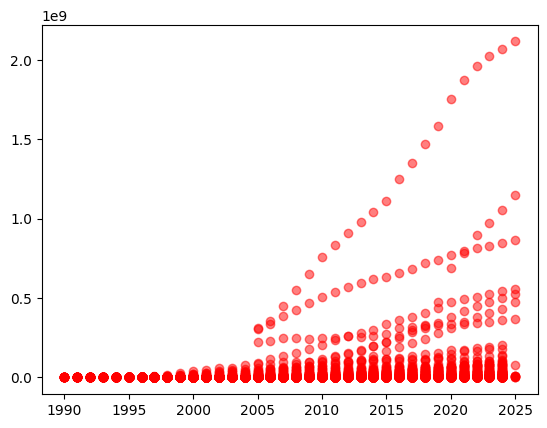

In [10]:
x = csv['Year']
y = csv['Number of people using the Internet']

graph_point = plt.scatter(x, y, marker = 'o', c = 'red', alpha = 0.5)
graph_point

# 3 - MODEL TRAINING

A partir de los datos que previamente fueron procesados, se aplicaran 3 modelos de regresion para predecir un numero estimado de personas de internet a futuro, o bien, desde el ultimo año que se ha registrado. Los modelos de regresion que se utilizaran son:

1. **Lineal:** Se utiliza regresión lineal de mínimos cuadrados. El modelo se ajusta con coeficientes w = (w1,…, wp) para minimizar la suma residual de cuadrados entre los objetivos observados en el conjunto de datos y los objetivos predichos por la aproximación lineal.

2. **Polinomial:** Genera una función para representar el crecimiento, de manera exponencial, del número de persona en Internet. A diferenecia del anterior, este adapta la función a partir a los datos registrados de acuerdo la cantidad de coeficiente de que implementará en la funcion polinomial. Para este laboratorio se utilizarán las siguientes 3 funciones:

> $ Y = M  X + B $ (1er Grado)

> $ Y = {A  X^2} + {B  X} + C $ (2do Grado)

> $ Y = {A  X^3} + {B  X^2} + {C  X} + D $ (3er Grado)

3. **Gradiente Descendente Estocástico**: Este modelo permite pronosticar a los años futuros (2021 - 2025) el n° estimado de personas de internet en un pais. Mediante los datos iniciales, estudia la tendencia del crecimiento de personas en internet, se hacen los calculos utilizando el gradiente de la función de pérdida generar una funcion lineal de las predicciones

# 4 - MODEL EVALUATION

**REGRESIÓN LINEAL DE MÍNIMOS CUADRADOS**






---



In [11]:
# Se crean los diccionarios models y predictions_dict, el primero almacenará los modelos de regresión lineal entrenados de cada país, y el segundo almacenará las predicciones realizadas por país.
models = {}
predictions_dict = {}

# Se almacena cada país en una lista
countries = csv['Entity'].unique()

In [12]:
# Se iterará sobre la lista de paises, creando y entrenando un modelo para cada uno.
for country in countries:
  country_data = csv[csv['Entity'] == country]

  # Se define la variable X e y, la primera corresponde a los años y la segunda a la cantidad de usuarios de Internet, lo cual es lo que queremos predecir
  X = country_data['Year'].values.reshape(-1,1)
  y = country_data['Number of people using the Internet'].values

  # Se dividen los datos. 80% de estos serán utilizados para entrenar los modelos y el 20% para testeo.
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

  # Se crea el modelo de regresión lineal y se entrena utilizando la función fit.
  model = LinearRegression()
  model.fit(X_train, y_train)

  models[country] = model

  # Se definen los años a predecir, desde el año siguiente después del último (2021), hasta una cantidad determinada.
  year_start = csv['Year'].max() + 1
  year_end = year_start + 5
  year_future = np.arange(year_start, year_end).reshape(-1,1)

  # Se predice la cantidad de usuarios de Internet que tendrá cada país los años siguientes
  predictions_dict[country] = model.predict(year_future)

In [13]:
# Se crea un DataFrame con una columna con los años predecidos, cada país y su respectiva predicción.
predictions_df = pd.DataFrame(year_future, columns=['Year'])
predictions_df = pd.concat([predictions_df, pd.DataFrame(predictions_dict)], axis=1)

In [14]:
# Se configura el formato de visualización de los números en forma de enteros sin decimales (originalmente se mostraban en notación científica).
pd.options.display.float_format = '{:.0f}'.format
print(predictions_df)

   Year  Afghanistan  Albania  Algeria  Andorra   Angola  Antigua and Barbuda  \
0  2026      7734697  2363613 29573737    96150 12740144                84175   
1  2027      8101296  2449692 30708360    99278 13264461                87026   
2  2028      8467895  2535770 31842982   102406 13788779                89877   
3  2029      8834494  2621849 32977605   105533 14313096                92728   
4  2030      9201093  2707928 34112228   108661 14837413                95579   

   Argentina  Armenia  Aruba  ...  United Kingdom  \
0   44565583  2565791 158486  ...        80512454   
1   46085656  2661009 164482  ...        82851359   
2   47605728  2756227 170478  ...        85190265   
3   49125801  2851445 176473  ...        87529170   
4   50645874  2946664 182469  ...        89868076   

   United States Virgin Islands  Uruguay  Uzbekistan  Vanuatu  Venezuela  \
0                         86213  3456884    27667982    73235   23532990   
1                         88950  3574085  

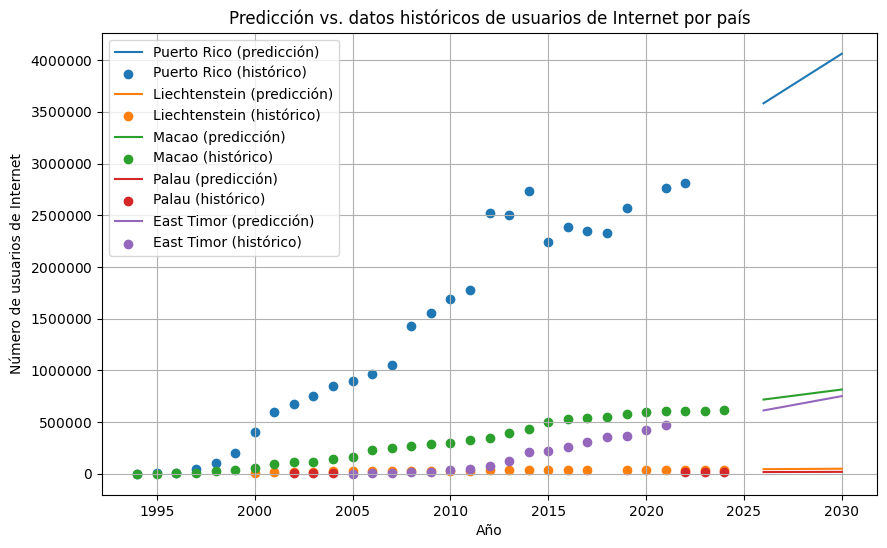

In [16]:
# Seleccionar al azar cinco países
random_countries = random.sample(list(predictions_dict.keys()), 5)

plt.figure(figsize=(10, 6))

# Graficar las predicciones y los datos históricos de los países elegidos
for country in random_countries:
    plt.plot(year_future, predictions_dict[country], label=f'{country} (predicción)')
    country_data = csv[csv['Entity'] == country]
    plt.scatter(country_data['Year'], country_data['Number of people using the Internet'], label=f'{country} (histórico)', marker='o')

plt.gca().yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
plt.ticklabel_format(style='plain', axis='y')
plt.title('Predicción vs. datos históricos de usuarios de Internet por país')
plt.xlabel('Año')
plt.ylabel('Número de usuarios de Internet')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


**REGRESION POLINOMIAL (GOOD FIT)**


---



Funcion para generar el texto informando las preddciones en los proximos 3 años desde el ultimo año registrado

In [17]:
def texto_predecir(year, predict):
  texto_predecir = ""
  for i in range(len(year)):
    texto_predecir += f"{year[i]}, cantidad estimada de usuarios: {predict[i]:.0f}\n"
  return texto_predecir

* Sentencia para ejecutar el modelo regresion polinomial. Dado un pais, se procede a calcular la funcion polinomial (1er, 2do y 3er grado) utilizando la informacion del numero de personas de intenet en cada año.

* Tambien, mediante las funciones permite predecir de manera estimada la cantidad de personas de internet para los proximos 3 años desde el ultimo año registrado.

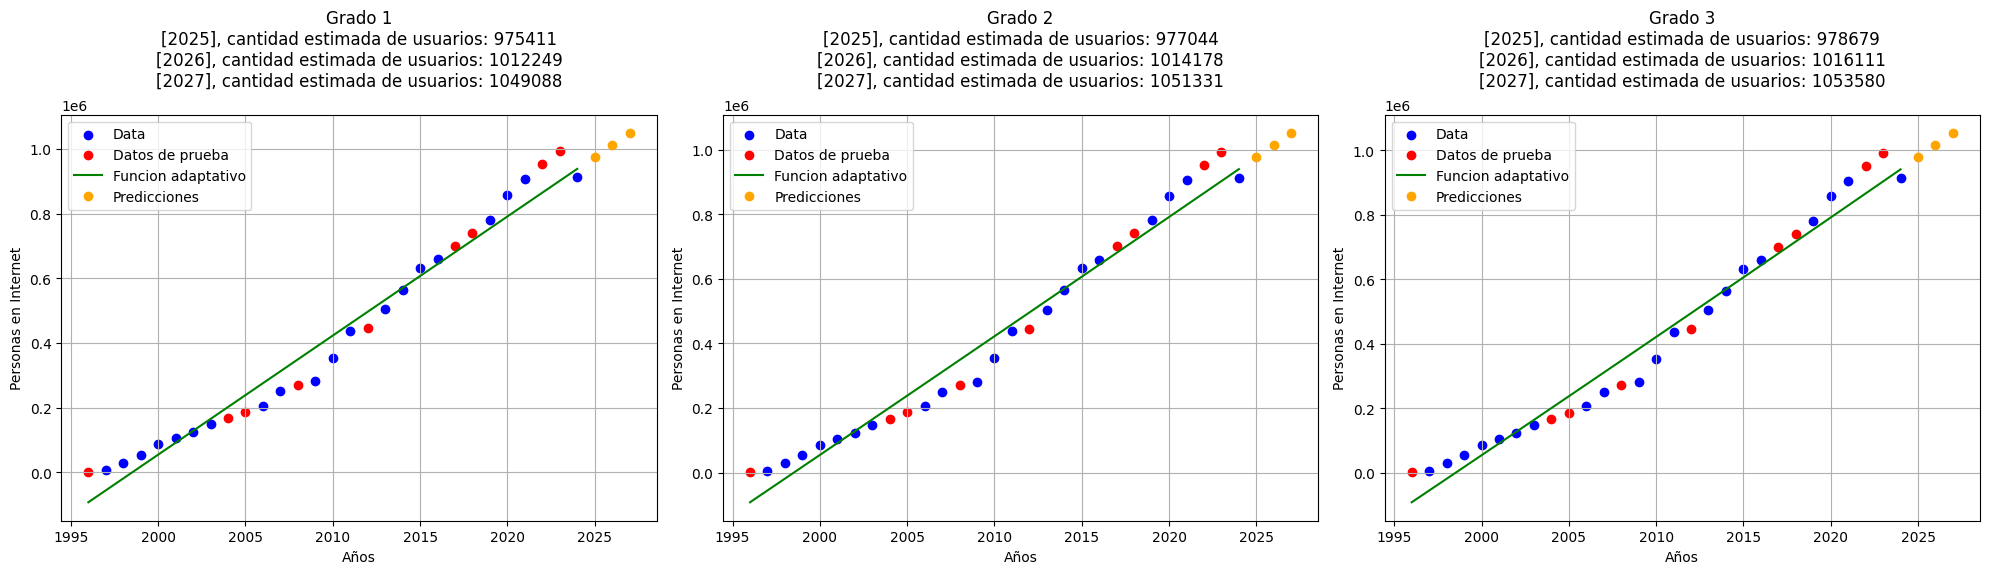

In [18]:
data = csv

pais = ['Mauritius'] # Aqui puede cambiar el pais que desea probar (favor de escribir el pais en Ingles)

# Dado el pais, obtengo la informacion de los usuarios en internet paralelo a los años
data = data[data['Entity'].isin(pais)]
users = np.array(data['Number of people using the Internet'])
years = np.array(data['Year'])


years_train, years_test, population_train, population_test = train_test_split(years, users, test_size=0.3, random_state=42)

# Grados del polinomio
degrees = [1, 2, 3]
plt.figure(figsize=(20, 6))

for i, degree in enumerate(degrees):

    # Aplico la funcion polinomial segun el grado de [i]
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(years_train[:, np.newaxis], population_train)
    population_pred_train = model.predict(years_train[:, np.newaxis])
    population_pred_test = model.predict(years_test[:, np.newaxis])

    # Genero 3 años a futuro despues del ultimo año registrado
    next = years[-1]
    X_new = np.array([next + 1, next + 2, next + 3]).reshape(-1, 1)
    predictions = model.predict(X_new)
    text = texto_predecir(X_new, predictions)


    # Graficar los resultados
    plt.subplot(1, len(degrees), i + 1)
    plt.scatter(years_train, population_train, label='Data', color='blue')
    plt.scatter(years_test, population_test, label='Datos de prueba', color='red')
    plt.plot(years, model.predict(years[:, np.newaxis]), label='Funcion adaptativo', color='green')
    plt.plot(X_new, predictions, 'o', label='Predicciones', color='orange')
    plt.title('Grado {}\n{}'.format(degree, text))

    plt.xlabel('Años')
    plt.ylabel('Personas en Internet')
    plt.legend()
    plt.grid(True)


plt.tight_layout()
plt.show()


**Gradiente Descendente Estocástico**


---



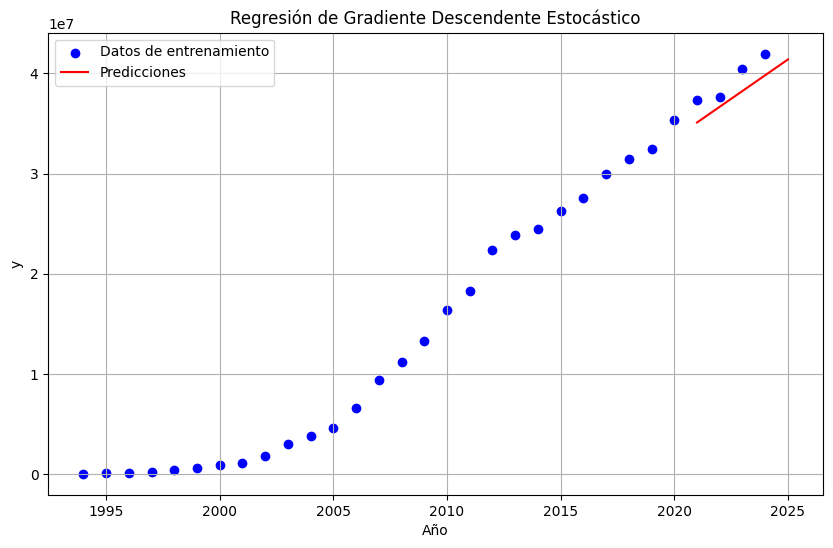

In [19]:
data = csv

pais = ['Colombia'] # Aqui puede cambiar el pais que desea probar (favor de escribir el pais en Ingles)

# Dado el pais, obtengo la informacion de los usuarios en internet paralelo a los años
data = data[data['Entity'].isin(pais)]
y = np.array(data['Number of people using the Internet'])
x = np.array(data['Year'])

# Escalar características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x.reshape(-1, 1))

# Inicializar el modelo de regresión de gradiente descendente estocástico
sgd_regressor = SGDRegressor(max_iter=1000, tol=1e-3, random_state=42)

# Ajustar el modelo a los datos
sgd_regressor.fit(X_scaled, y)

# Enterga un conjunto de años a futuro
X_test = np.array([[2021], [2022], [2023], [2024], [2025]])
X_test_scaled = scaler.transform(X_test)

# Hacer predicciones
y_pred = sgd_regressor.predict(X_test_scaled)

# Graficar resultados
plt.figure(figsize=(10, 6))
plt.scatter(x, y, c='blue', label='Datos de entrenamiento')
plt.plot(X_test.ravel(), y_pred, color='red', label='Predicciones')
plt.xlabel('Año')
plt.ylabel('y')
plt.title('Regresión de Gradiente Descendente Estocástico')
plt.legend()
plt.grid(True)
plt.show()
